# Test loading a NASA NEX-GDDP-CMIP6 models output to compare with ERA5 0.25 $^{\circ}$ grid

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = '../../../Data/CMIP6/NEX-GDDP-CMIP6/CESM2/raw/tas_day_CESM2_historical_r4i1p1f1_gn_1961_v2.0.nc'

ds = xr.open_mfdataset(file_path, compat='override')

In [3]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 365, lat: 600, lon: 1440)
Coordinates:
  * time     (time) object 3kB 1961-01-01 00:00:00 ... 1961-12-31 00:00:00
  * lat      (lat) float64 5kB -59.88 -59.62 -59.38 -59.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    tas      (time, lat, lon) float32 1GB dask.array<chunksize=(1, 600, 1440), meta=np.ndarray>
Attributes: (12/21)
    activity:              NEX-GDDP-CMIP6
    Conventions:           CF-1.7
    frequency:             day
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    variant_label:         r4i1p1f1
    product:               output
    ...                    ...
    cmip6_institution_id:  NCAR
    cmip6_license:         CC-BY-SA 4.0
    contact:               Dr. Bridget Thrasher: bridget@climateanalyticsgrou...
    creation_date:         Sat Nov 16 20:26:20 PST 2024
    disclaimer:            These data are considered provisional and subject ...
    tracking_id:           da98142a-5e4f-4c80-99d1-83ce9d7f6351

### Need to fix time variable and adjust longitude to be -180 to 180

In [7]:
ds['time'] = ds.indexes['time'].to_datetimeindex()

In [8]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 365, lat: 600, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
  * lat      (lat) float64 5kB -59.88 -59.62 -59.38 -59.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    tas      (time, lat, lon) float32 1GB dask.array<chunksize=(1, 600, 1440), meta=np.ndarray>
Attributes: (12/21)
    activity:              NEX-GDDP-CMIP6
    Conventions:           CF-1.7
    frequency:             day
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    variant_label:         r4i1p1f1
    product:               output
    ...                    ...
    cmip6_institution_id:  NCAR
    cmip6_license:         CC-BY-SA 4.0
    contact:               Dr. Bridget Thrasher: bridget@climateanalyticsgrou...
    creation_date:         Sat Nov 16 20:26:20 PST 2024
    disclaimer:            These data are considered provisional and subject ...
    tracking_id:           da98142a-5e4f-4c80-99d1-83ce9d7f6351

#### Adjust Lon to run from -180 to 180 instead of 0 to 360

In [9]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = ds.coords['lon'].attrs  
lat_atrib = ds.coords['lat'].attrs
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds_fixed = ds.sortby(ds.lon)
ds_fixed

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 365, lat: 600, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
  * lat      (lat) float64 5kB -59.88 -59.62 -59.38 -59.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    tas      (time, lat, lon) float32 1GB dask.array<chunksize=(1, 600, 1440), meta=np.ndarray>
Attributes: (12/21)
    activity:              NEX-GDDP-CMIP6
    Conventions:           CF-1.7
    frequency:             day
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    variant_label:         r4i1p1f1
    product:               output
    ...                    ...
    cmip6_institution_id:  NCAR
    cmip6_license:         CC-BY-SA 4.0
    contact:               Dr. Bridget Thrasher: bridget@climateanalyticsgrou...
    creation_date:         Sat Nov 16 20:26:20 PST 2024
    disclaimer:            These data are considered provisional and subject ...
    tracking_id:           da98142a-5e4f-4c80-99d1-83ce9d7f6351

Text(0.5, 1.0, 'Location: 49.125, -123.125')

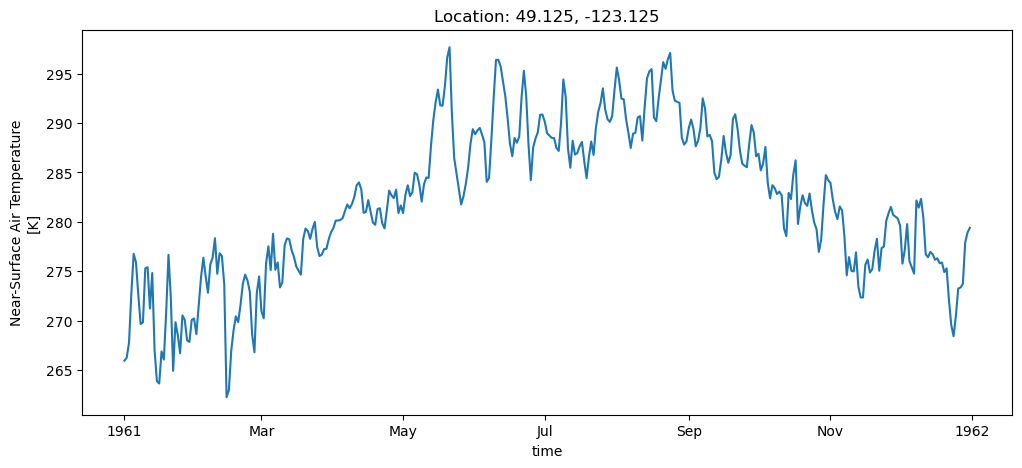

In [26]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116
plt.figure(figsize=(12,5))
ds_fixed.tas.sel(lat=input_lat, lon=input_lon, method="nearest").plot()
plt.title("Location: "+str(ds_fixed.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lat.values)+", "+str(ds_fixed.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lon.values))

### read in one ERA5 file for comparison

In [13]:
filepath = "../../../Data/ERA5-global/Baseline/1961/download_daily_mean_2m_temperature_1961_*.nc"
ds_era5 = xr.open_mfdataset(filepath)
ds_era5

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 365, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    realization  int64 8B 0
Data variables:
    t2m          (time, lat, lon) float32 2GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

<xarray.DataArray 't2m' (time: 365)> Size: 1kB
dask.array<getitem, shape=(365,), dtype=float32, chunksize=(31,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
    realization  int64 8B 0
    lat          float64 8B 49.25
    lon          float64 8B -123.0
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real


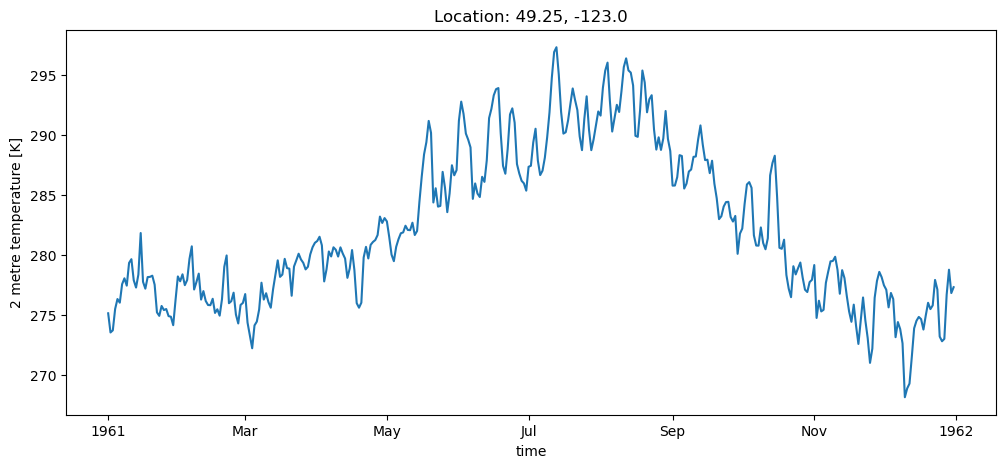

In [25]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116
plt.figure(figsize=(12,5))
ds_era5.t2m.sel(lat=input_lat, lon=input_lon, method="nearest").plot()
plt.title("Location: "+str(ds_era5.t2m.sel(lat=input_lat, lon=input_lon, method="nearest").lat.values)+", "+str(ds_era5.t2m.sel(lat=input_lat, lon=input_lon, method="nearest").lon.values))
print(ds_era5.t2m.sel(lat=input_lat, lon=input_lon, method="nearest"))

In [24]:
str(ds_era5.t2m.sel(lat=input_lat, lon=input_lon, method="nearest").lat.values)

'49.25'

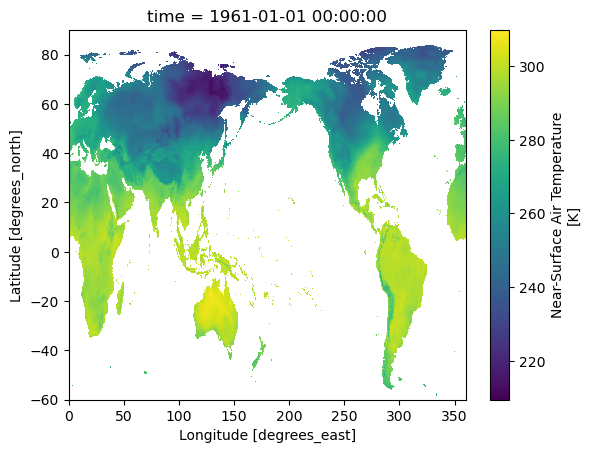

In [6]:
ds.tas.sel(time="1961-01-01").plot()